# Lab 4: Model-Based Offline Optimization
## Piotr Błaszczyk

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

# printy aby sie upewnić że działa git
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
elif device.type == "mps":
    print("Using Apple MPS backend (Metal)")
else:
    print("Using CPU - good luck, have fun")

# sanity check - czy tensor faktycznie idzie na device
x = torch.tensor([1.0, 2.0]).to(device)
print(f"Tensor device: {x.device}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU
CUDA version: 12.4
Tensor device: cuda:0


### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [2]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [3]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [4]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 487.0478, Val Loss: 445.7338
Epoch 20/100, Train Loss: 310.1397, Val Loss: 301.5990
Epoch 30/100, Train Loss: 244.5428, Val Loss: 240.6788
Epoch 40/100, Train Loss: 204.9706, Val Loss: 202.5523
Epoch 50/100, Train Loss: 184.0761, Val Loss: 183.9453
Epoch 60/100, Train Loss: 167.3353, Val Loss: 170.0143
Epoch 70/100, Train Loss: 155.9124, Val Loss: 155.4528
Epoch 80/100, Train Loss: 149.2028, Val Loss: 149.7143
Epoch 90/100, Train Loss: 140.4323, Val Loss: 138.6362
Epoch 100/100, Train Loss: 131.5926, Val Loss: 131.6210
Test Loss: 129.6684


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

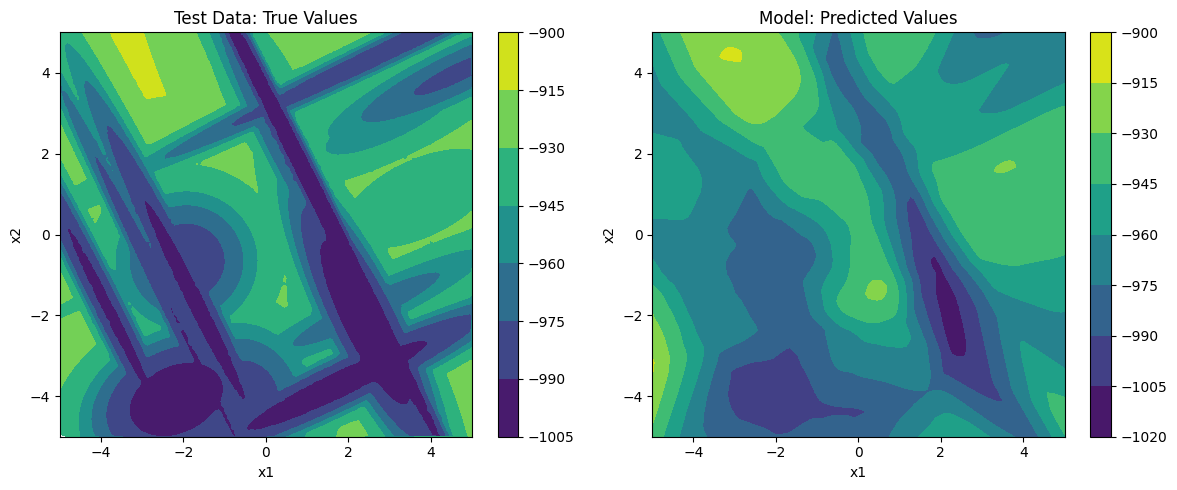

In [5]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

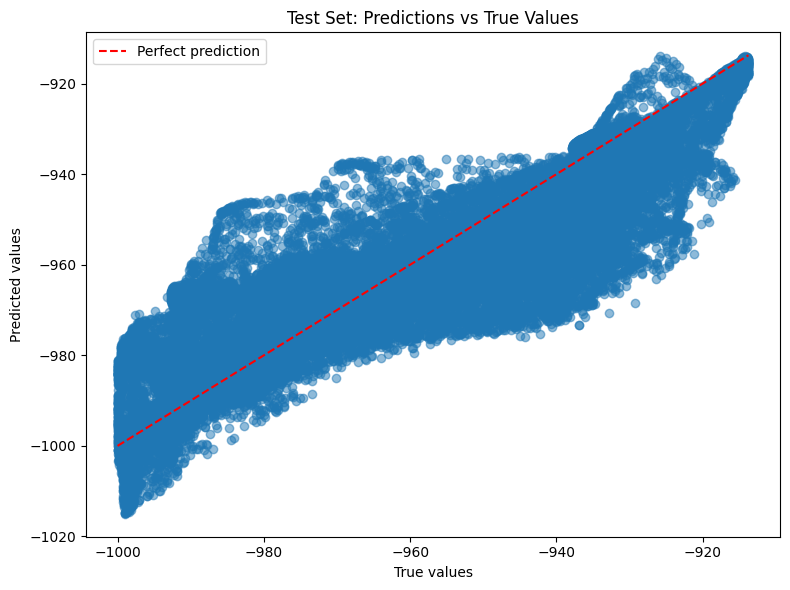

In [6]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [7]:
import random

def optimize_model(
    model: nn.Module, num_steps: int = 1000
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()
    
    # Select random starting point in [-5, 5]^2
    # rand_point = (random.uniform(-5, 5), random.uniform(-5, 5))
    
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)
    # raise NotImplementedError("Not implemented")
    # optimizer = None # TODO: select optimizer
    optimizer = torch.optim.Adam([x], lr=0.01)

    best_x = x.detach().clone()
    best_y = model(x).item()

    optimizer = torch.optim.Adam([x], lr=0.01)

    for _ in range(num_steps):
        optimizer.zero_grad()
        # Predict output (our output - result of the model is the function we want to minimize)
        # Compute gradients (gradients of our model)
        # Update x
        # Enforce domain constraints [-5, 5]

        optimizer.zero_grad()

        y = model(x)

        y.backward()

        optimizer.step()

        with torch.no_grad():
            x.clamp_(-5.0, 5.0)

        current_y = model(x).item()
        if current_y < best_y:
            best_y = current_y
            best_x = x.detach().clone()

    return best_x, best_y

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [8]:
#! pip install coco-experiment cocopp

     ---------------------------------------- 0.0/8.6 MB ? eta -:--:--
     - -------------------------------------- 0.3/8.6 MB ? eta -:--:--
     ---- ----------------------------------- 1.0/8.6 MB 3.0 MB/s eta 0:00:03
     ------- -------------------------------- 1.6/8.6 MB 3.0 MB/s eta 0:00:03
     --------- ------------------------------ 2.1/8.6 MB 3.3 MB/s eta 0:00:03
     ------------ --------------------------- 2.6/8.6 MB 3.0 MB/s eta 0:00:02
     -------------- ------------------------- 3.1/8.6 MB 3.0 MB/s eta 0:00:02
     ----------------- ---------------------- 3.7/8.6 MB 2.8 MB/s eta 0:00:02
     ------------------- -------------------- 4.2/8.6 MB 2.7 MB/s eta 0:00:02
     -------------------- ------------------- 4.5/8.6 MB 2.6 MB/s eta 0:00:02
     ----------------------- ---------------- 5.0/8.6 MB 2.5 MB/s eta 0:00:02
     ------------------------ --------------- 5.2/8.6 MB 2.5 MB/s eta 0:00:02
     -------------------------- ------------- 5.8/8.6 MB 2.4 MB/s eta 0:00:02



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Exercise 1

Training set size: 100
Epoch 20/100, Train Loss: 882861.5625, Val Loss: 879750.1336
Epoch 40/100, Train Loss: 789138.2500, Val Loss: 783187.4213
Epoch 60/100, Train Loss: 624818.0000, Val Loss: 615671.0495
Epoch 80/100, Train Loss: 408201.9375, Val Loss: 396610.2104
Epoch 100/100, Train Loss: 210721.5781, Val Loss: 198056.7396
Final Test MSE for train_size=100: 198718.3334


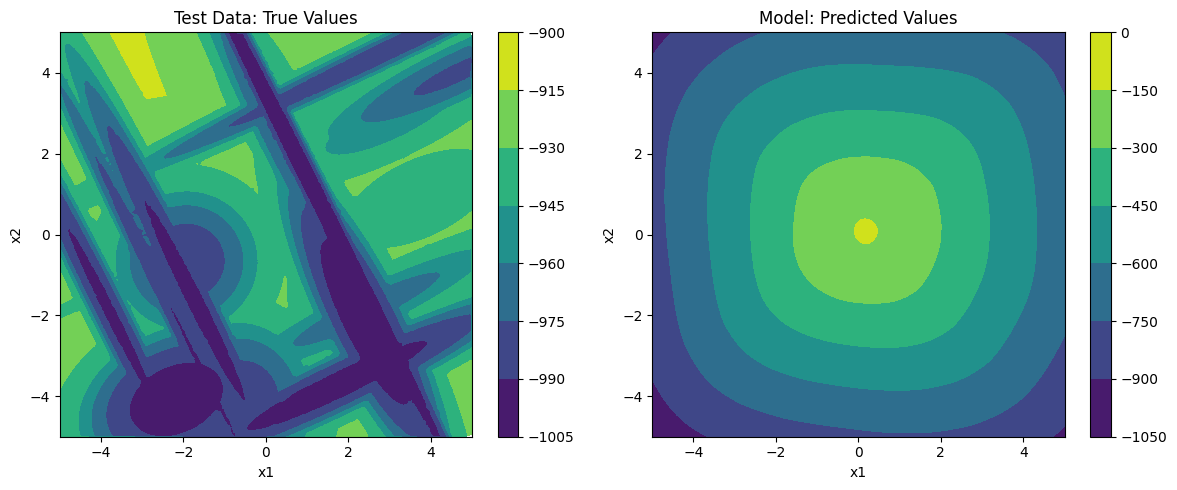

Training set size: 1000
Epoch 20/100, Train Loss: 428701.0858, Val Loss: 413816.4279
Epoch 40/100, Train Loss: 70557.0682, Val Loss: 78652.7122
Epoch 60/100, Train Loss: 64041.8901, Val Loss: 71780.0904
Epoch 80/100, Train Loss: 57514.4358, Val Loss: 64306.1204
Epoch 100/100, Train Loss: 50077.4142, Val Loss: 55700.9981
Final Test MSE for train_size=1000: 55905.6572


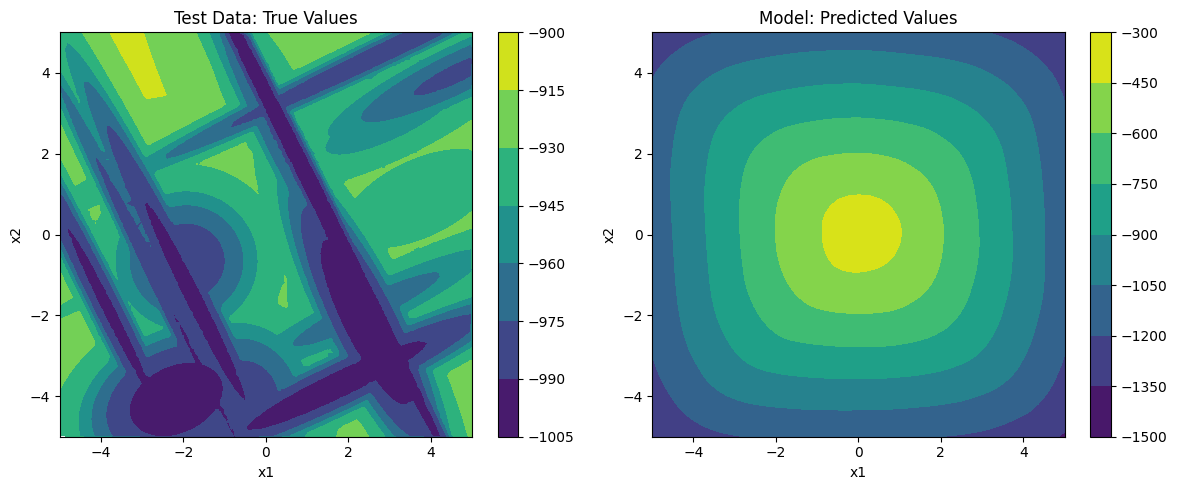

Training set size: 5000
Epoch 20/100, Train Loss: 50324.9421, Val Loss: 49582.3905
Epoch 40/100, Train Loss: 2981.0191, Val Loss: 2683.2445
Epoch 60/100, Train Loss: 462.7585, Val Loss: 474.2083
Epoch 80/100, Train Loss: 368.5840, Val Loss: 382.0809
Epoch 100/100, Train Loss: 324.7347, Val Loss: 332.5758
Final Test MSE for train_size=5000: 332.5862


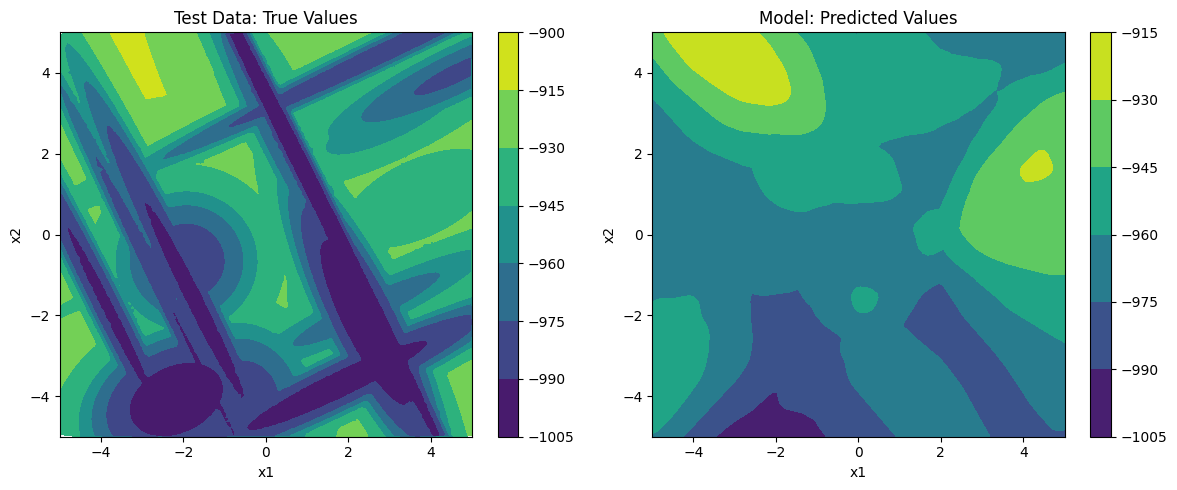

Training set size: 10000
Epoch 20/100, Train Loss: 9808.9523, Val Loss: 8473.3413
Epoch 40/100, Train Loss: 399.9888, Val Loss: 401.9718
Epoch 60/100, Train Loss: 340.0147, Val Loss: 340.2729
Epoch 80/100, Train Loss: 298.0818, Val Loss: 295.3501
Epoch 100/100, Train Loss: 255.7885, Val Loss: 260.4831
Final Test MSE for train_size=10000: 263.1008


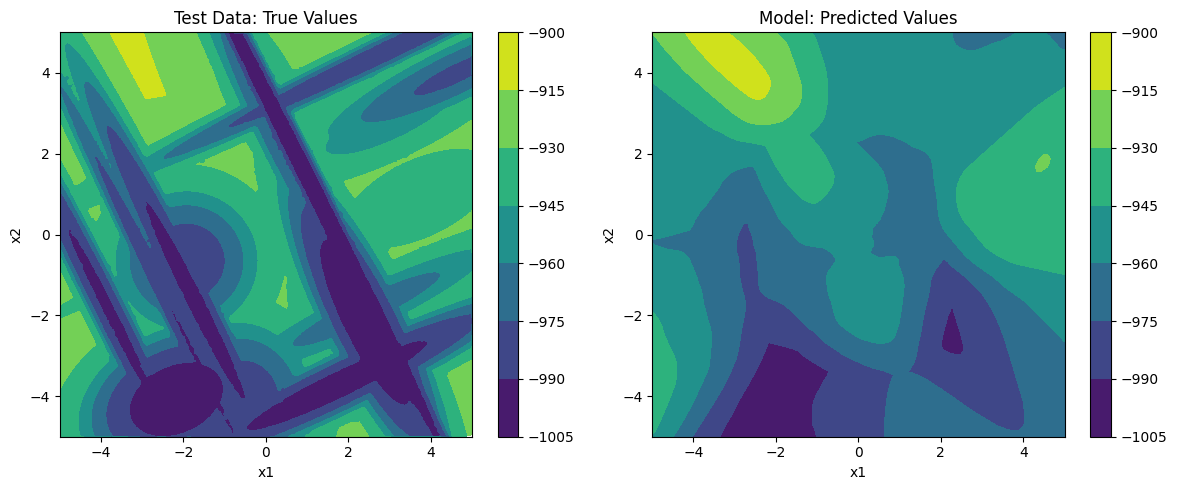

Training set size: 50000
Epoch 20/100, Train Loss: 206.1806, Val Loss: 203.1625
Epoch 40/100, Train Loss: 133.9429, Val Loss: 141.7009
Epoch 60/100, Train Loss: 111.6970, Val Loss: 113.0885
Epoch 80/100, Train Loss: 100.7660, Val Loss: 99.5367
Epoch 100/100, Train Loss: 90.6810, Val Loss: 97.8295
Final Test MSE for train_size=50000: 96.9476


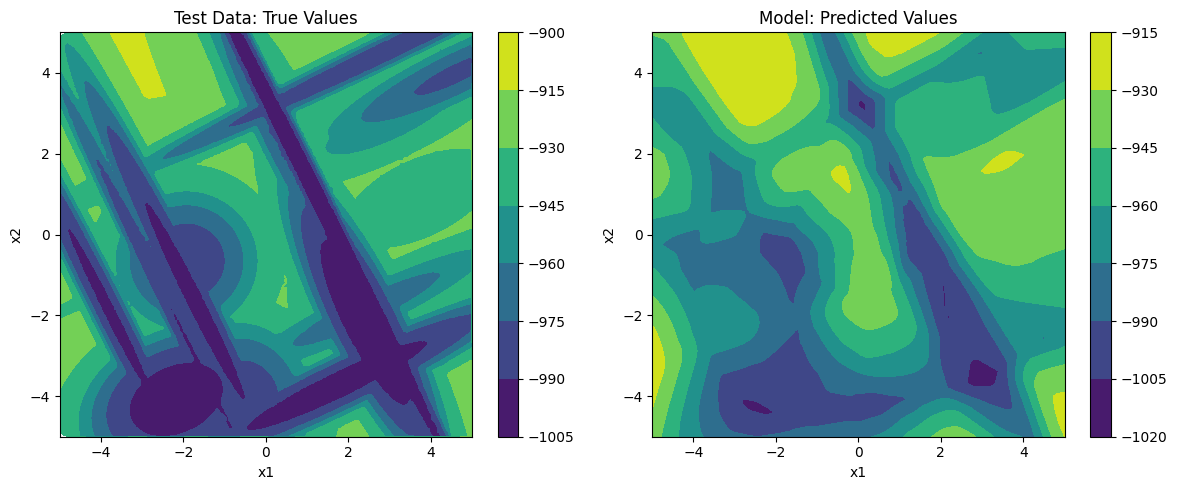


Summary:
train_size=   100 | train_perc=0.0010 | val_perc=0.6990 | test_perc=0.3000 | test_MSE=198718.3334
train_size=  1000 | train_perc=0.0100 | val_perc=0.6900 | test_perc=0.3000 | test_MSE=55905.6572
train_size=  5000 | train_perc=0.0500 | val_perc=0.6500 | test_perc=0.3000 | test_MSE=332.5862
train_size= 10000 | train_perc=0.1000 | val_perc=0.6000 | test_perc=0.3000 | test_MSE=263.1008
train_size= 50000 | train_perc=0.5000 | val_perc=0.2000 | test_perc=0.3000 | test_MSE=96.9476


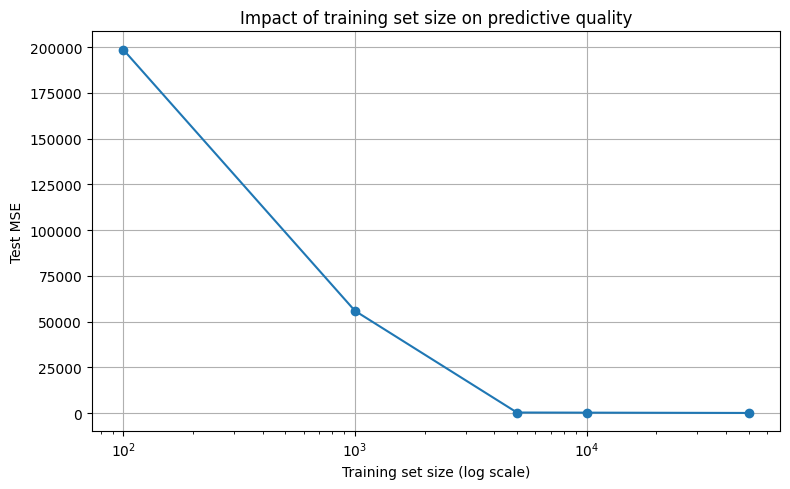

In [8]:
train_sizes = [100, 1000, 5000, 10_000, 50_000]
file_path = "./bbob_f022_i01_d02_samples.csv"

num_samples = 100_000

fixed_test_size = 30_000
test_perc = fixed_test_size / num_samples

results = []

for train_size in train_sizes:
    print("=" * 80)
    print(f"Training set size: {train_size}")

    train_perc = train_size / num_samples
    val_perc = 1.0 - train_perc - test_perc

    if val_perc <= 0:
        raise ValueError(
            f"Invalid split for train_size={train_size}: "
            f"train_perc={train_perc:.4f}, val_perc={val_perc:.4f}, test_perc={test_perc:.4f}"
        )

    train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
        file_path,
        batch_size=256,
        train_perc=train_perc,
        val_perc=val_perc,
    )

    model = MLP().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 100
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_dataloader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_dataloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)

        val_loss /= len(val_dataloader.dataset)
        val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs}, "
                f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
            )

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)

    test_loss /= len(test_dataloader.dataset)

    print(f"Final Test MSE for train_size={train_size}: {test_loss:.4f}")

    results.append({
        "train_size": train_size,
        "train_perc": train_perc,
        "val_perc": val_perc,
        "test_perc": test_perc,
        "test_mse": test_loss,
        "model": model,
        "test_dataloader": test_dataloader,
    })

    plot_contour_comparison(
        model,
        test_dataloader,
        device,
    )

print("\nSummary:")
for r in results:
    print(
        f"train_size={r['train_size']:>6} | "
        f"train_perc={r['train_perc']:.4f} | "
        f"val_perc={r['val_perc']:.4f} | "
        f"test_perc={r['test_perc']:.4f} | "
        f"test_MSE={r['test_mse']:.4f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(
    [r["train_size"] for r in results],
    [r["test_mse"] for r in results],
    marker="o",
)
plt.xscale("log")
plt.xlabel("Training set size (log scale)")
plt.ylabel("Test MSE")
plt.title("Impact of training set size on predictive quality")
plt.grid(True)
plt.tight_layout()
plt.show()


#### no więc dla trainig size 100 oraz 1000 MSE wyszło mega wysokie, no i wykres nie przedstawiał nic co jakkolwiek by się sensownie miało do rzeczywistośći. Dopiero od 5000 Zaczyna to jakkolwiek przypominać rzeczywstą funkcję. Dla 50_000 już to sensowanie wygląda, aczkolwiek nieidealnie, ale już za pomocą naszego "surrogata" widać, gdzie warto szukać minimum / maximum. 

### Excercise 2

Run 1: model_y=-994.4305, true_y=-997.1583
Run 2: model_y=-1004.2534, true_y=-998.1083
Run 3: model_y=-981.8247, true_y=-973.6625
Run 4: model_y=-1007.4634, true_y=-997.7949
Run 5: model_y=-994.4267, true_y=-997.1741
Run 6: model_y=-994.4249, true_y=-997.1485
Run 7: model_y=-1010.2668, true_y=-999.5423
Run 8: model_y=-965.8254, true_y=-984.7156
Run 9: model_y=-994.4302, true_y=-997.1644
Run 10: model_y=-989.6442, true_y=-987.7547


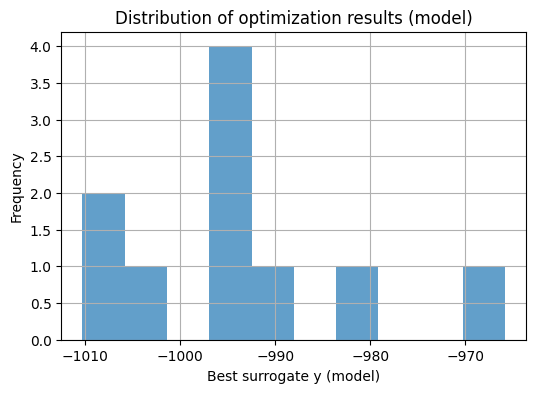

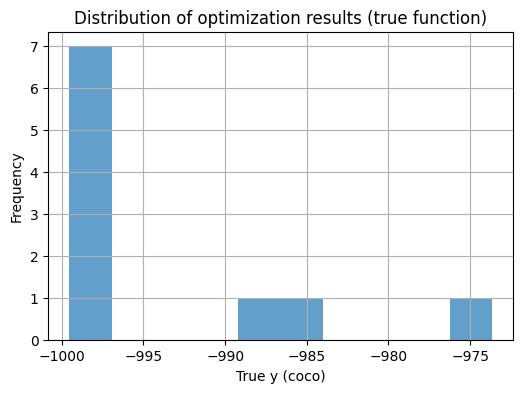

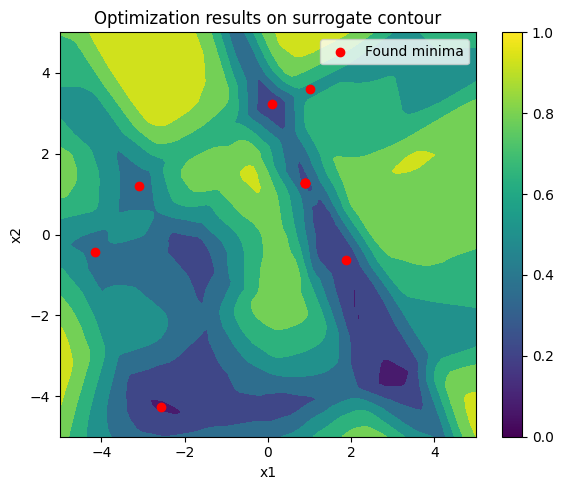


Comparison (model vs true):
1: model=-994.4305 | true=-997.1583
2: model=-1004.2534 | true=-998.1083
3: model=-981.8247 | true=-973.6625
4: model=-1007.4634 | true=-997.7949
5: model=-994.4267 | true=-997.1741
6: model=-994.4249 | true=-997.1485
7: model=-1010.2668 | true=-999.5423
8: model=-965.8254 | true=-984.7156
9: model=-994.4302 | true=-997.1644
10: model=-989.6442 | true=-987.7547


In [12]:
from cocoex import Suite
import numpy as np
import matplotlib.pyplot as plt
import torch

num_runs = 10
function_id = 22  

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
problem = next(iter(suite))

best_x_list = []
best_y_model_list = []
best_y_true_list = []

for i in range(num_runs):
    best_x, best_y_model = optimize_model(model)

    x_np = best_x.detach().cpu().numpy().reshape(-1).astype(np.float64)
    x_np = np.clip(x_np, -5.0, 5.0)

    y_true = problem(x_np)

    best_x_list.append(x_np)
    best_y_model_list.append(best_y_model)
    best_y_true_list.append(y_true)

    print(f"Run {i+1}: model_y={best_y_model:.4f}, true_y={y_true:.4f}")

best_x_array = np.array(best_x_list)

plt.figure(figsize=(6, 4))
plt.hist(best_y_model_list, bins=10, alpha=0.7)
plt.xlabel("Best surrogate y (model)")
plt.ylabel("Frequency")
plt.title("Distribution of optimization results (model)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(best_y_true_list, bins=10, alpha=0.7)
plt.xlabel("True y (coco)")
plt.ylabel("Frequency")
plt.title("Distribution of optimization results (true function)")
plt.grid(True)
plt.show()

def plot_solutions_on_contour(model, test_dataloader, solutions, device):
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()

    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(X1, X2, Z_pred)

    solutions = np.array(solutions)
    plt.scatter(solutions[:, 0], solutions[:, 1], c="red", label="Found minima")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Optimization results on surrogate contour")
    plt.legend()
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_solutions_on_contour(model, test_dataloader, best_x_list, device)

print("\nComparison (model vs true):")
for i in range(num_runs):
    print(
        f"{i+1}: model={best_y_model_list[i]:.4f} | true={best_y_true_list[i]:.4f}"
    )

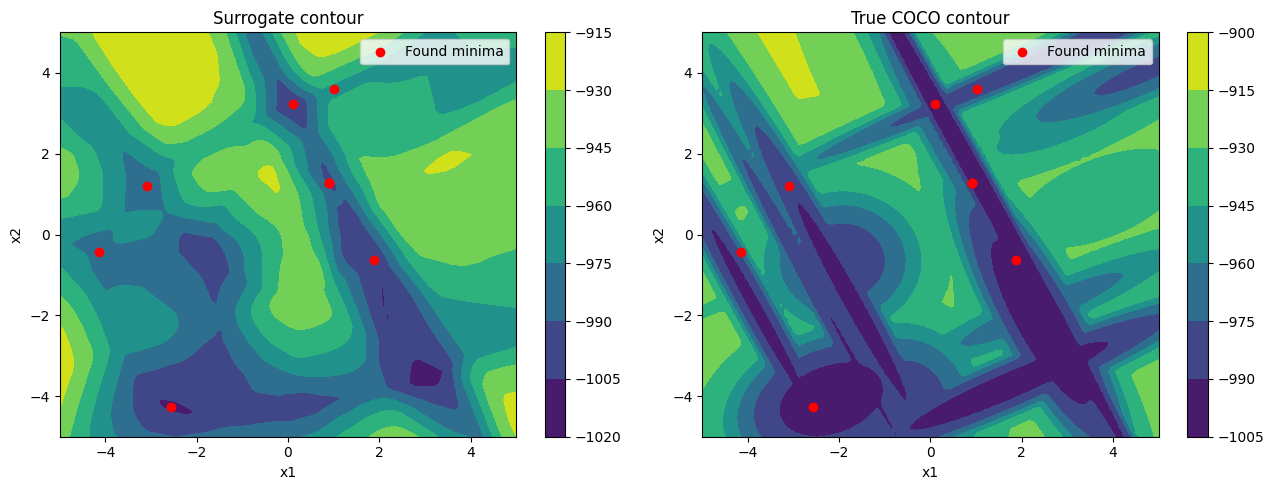

In [13]:
def plot_surrogate_vs_true_contours(model, test_dataloader, solutions, device, problem):
    test_inputs_list = []

    for inputs, _ in test_dataloader:
        test_inputs_list.append(inputs.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()

    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))

    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)
    model.eval()
    with torch.no_grad():
        surrogate_preds = model(grid_tensor).cpu().numpy().flatten()

    Z_surrogate = surrogate_preds.reshape(X1.shape)

    true_vals = np.array([problem(np.array(p, dtype=np.float64)) for p in grid_points])
    Z_true = true_vals.reshape(X1.shape)

    solutions = np.array(solutions)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    contour1 = ax1.contourf(X1, X2, Z_surrogate)
    ax1.scatter(solutions[:, 0], solutions[:, 1], c="red", label="Found minima")
    ax1.set_title("Surrogate contour")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    ax1.legend()
    plt.colorbar(contour1, ax=ax1)

    contour2 = ax2.contourf(X1, X2, Z_true)
    ax2.scatter(solutions[:, 0], solutions[:, 1], c="red", label="Found minima")
    ax2.set_title("True COCO contour")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    ax2.legend()
    plt.colorbar(contour2, ax=ax2)

    plt.tight_layout()
    plt.show()


plot_surrogate_vs_true_contours(model, test_dataloader, best_x_list, device, problem)

#### Nasz "surrogat" funkcji wypadł według mnie całkiem dobrze. Różnice w wartościach znalezionych minimów względem rzeczywistych są relatywnie niewielkie. Dodatkowo w side-by-side comparison dobrze widać, że mimo iż surrogate wizualnie jest bardziej "wygładzony" i nie oddaje wszystkich szczegółów funkcji, to lokalizacje minimów są bardzo zbliżone do rzeczywistych.

#### Wniosek: jeżeli naszym celem jest znalezienie przybliżonych lokalizacji minimów i nie zależy nam na dokładnym odwzorowaniu całej funkcji, to MBO "get's the job done" i może znacząco ograniczyć koszt obliczeń. Trzeba jednak pamiętać, że jest to podejście przybliżone - w zastosowaniach wymagających wysokiej precyzji lub niosących duże ryzyko błędu, takie uproszczenie może być ryzykowne